# Ejercicio 3 — Seguro (regresión logística)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fcaceres-create/caece-aprendizaje-artificial-u3-datamining/blob/main/notebooks/03_seguro_regresion_logistica.ipynb)

**Metodologías de Data Mining — Unidad 3**

Una aseguradora quiere estimar la **probabilidad de que un asegurado tenga un accidente este año**
(`AccEsteAño` = 1) según su **edad**, los **kilómetros anuales** (en miles) y si tuvo **accidentes el año
anterior**. Con esa probabilidad decide si otorga o no el seguro.

Como la variable respuesta es binaria (0/1), usamos **regresión logística**:

$$p = P(Y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \dots + \beta_k X_k)}}$$

## 1. Librerías y datos

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.metrics import accuracy_score, auc, confusion_matrix, f1_score, precision_score, recall_score, roc_curve

URL_DATOS = "https://raw.githubusercontent.com/fcaceres-create/caece-aprendizaje-artificial-u3-datamining/main/notebooks/datos/"

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def verificar(nombre, obtenido, esperado, decimales=2):
    """Compara un resultado con el valor de referencia de la cátedra (redondeado a `decimales`)."""
    ok = abs(obtenido - esperado) <= 0.5 * 10 ** -decimales + 1e-9
    print(f"{'✔' if ok else '✘'} {nombre}: obtenido = {obtenido:.{decimales}f}   esperado = {esperado}")

In [2]:
df = pd.read_csv(URL_DATOS + "ejercicio3.csv")

# Alternativa: subir el Excel de la cátedra a Colab (ícono de carpeta, a la izquierda) y leer la hoja:
# df = pd.read_excel("EjerciciosRegresion.xlsx", sheet_name="Ejercicio3")

df.index += 1
print(df["AccEsteAño"].value_counts().rename("casos"))
df.head()

AccEsteAño
0    18
1     7
Name: casos, dtype: int64


,Edad,MilesKm,AccAnterior,AccEsteAño
1,23,22.3000,1,1
2,32,35.3000,0,1
3,28,43.1000,1,1
4,45,38.8000,0,0
5,56,18.2000,0,0


## 2. Modelo logístico con los 25 casos

In [3]:
logit = smf.logit("AccEsteAño ~ Edad + MilesKm + AccAnterior", data=df).fit()
print(logit.summary())

Optimization terminated successfully.
         Current function value: 0.414588
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             AccEsteAño   No. Observations:                   25
Model:                          Logit   Df Residuals:                       21
Method:                           MLE   Df Model:                            3
Date:                Mon, 28 Sep 2026   Pseudo R-squ.:                  0.3008
Time:                        09:36:35   Log-Likelihood:                -10.365
converged:                       True   LL-Null:                       -14.824
Covariance Type:            nonrobust   LLR p-value:                   0.03040
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.5621      2.410     -0.233      0.816      -5.285       4.161
Edad           -0.0840    

Construimos la tabla de coeficientes "estilo SPSS", con el estadístico de **Wald** $= (B/EE)^2$ y el
**odds ratio** $= e^B$ con su intervalo de confianza del 95 %:

In [4]:
ic = logit.conf_int()
coeficientes = pd.DataFrame({
    "B": logit.params,
    "Error est.": logit.bse,
    "Wald": (logit.params / logit.bse) ** 2,
    "gl": 1,
    "p-valor": logit.pvalues,
    "Exp(B) = OR": np.exp(logit.params),
    "OR IC 95% inf.": np.exp(ic[0]),
    "OR IC 95% sup.": np.exp(ic[1]),
})
coeficientes

,B,Error est.,Wald,gl,p-valor,Exp(B) = OR,OR IC 95% inf.,OR IC 95% sup.
Intercept,-0.5621,2.4097,0.0544,1,0.8156,0.5700,0.0051,64.1263
Edad,-0.0840,0.0610,1.8957,1,0.1686,0.9195,0.8159,1.0362
MilesKm,0.0965,0.0554,3.0412,1,0.0812,1.1013,0.9881,1.2276
AccAnterior,0.1619,1.3226,0.0150,1,0.9026,1.1758,0.0880,15.7068


In [5]:
b = logit.params
print(f"logit(p) = {b['Intercept']:.4f} {b['Edad']:+.4f}·Edad {b['MilesKm']:+.4f}·MilesKm {b['AccAnterior']:+.4f}·AccAnterior\n")
verificar("Constante", b["Intercept"], -0.5621, 4)
verificar("Edad", b["Edad"], -0.0840, 4)
verificar("MilesKm", b["MilesKm"], 0.0965, 4)
verificar("AccAnterior", b["AccAnterior"], 0.1619, 4)

logit(p) = -0.5621 -0.0840·Edad +0.0965·MilesKm +0.1619·AccAnterior

✔ Constante: obtenido = -0.5621   esperado = -0.5621
✔ Edad: obtenido = -0.0840   esperado = -0.084
✔ MilesKm: obtenido = 0.0965   esperado = 0.0965
✔ AccAnterior: obtenido = 0.1619   esperado = 0.1619


### Interpretación de los odds ratio

In [6]:
sujetos = {
    "Edad": "Cada año adicional de edad",
    "MilesKm": "Cada mil km adicionales",
    "AccAnterior": "Haber tenido un accidente el año anterior",
}
for var, texto in sujetos.items():
    oratio = np.exp(b[var])
    cambio = (oratio - 1) * 100
    sentido = f"las aumenta un {cambio:.1f} %" if cambio > 0 else f"las reduce un {-cambio:.1f} %"
    print(f"• {texto} multiplica las chances de accidente por {oratio:.2f} ({sentido}).")

• Cada año adicional de edad multiplica las chances de accidente por 0.92 (las reduce un 8.1 %).
• Cada mil km adicionales multiplica las chances de accidente por 1.10 (las aumenta un 10.1 %).
• Haber tenido un accidente el año anterior multiplica las chances de accidente por 1.18 (las aumenta un 17.6 %).


## 3. Bondad de ajuste

- **−2LL**: desajuste del modelo (cuanto menor, mejor).
- **χ² de razón de verosimilitud** $= -2LL_{nulo} - (-2LL_{modelo})$: contrasta si el modelo es mejor que
  el que solo tiene la constante.
- **Pseudo-$R^2$**: Cox-Snell $= 1 - e^{2(LL_0 - LL)/n}$ y Nagelkerke, que lo reescala para que el máximo sea 1.

In [7]:
n = int(logit.nobs)
cox_snell = 1 - np.exp(2 * (logit.llnull - logit.llf) / n)
nagelkerke = cox_snell / (1 - np.exp(2 * logit.llnull / n))

ajuste = pd.Series({
    "−2LL modelo": -2 * logit.llf,
    "−2LL nulo": -2 * logit.llnull,
    "χ² razón de verosimilitud": logit.llr,
    "gl": logit.df_model,
    "p-valor (χ²)": logit.llr_pvalue,
    "R² Cox-Snell": cox_snell,
    "R² Nagelkerke": nagelkerke,
})
print(ajuste, "\n")
verificar("χ² de razón de verosimilitud", logit.llr, 8.92, 2)
verificar("p-valor del χ²", logit.llr_pvalue, 0.030, 3)
verificar("R² de Nagelkerke", nagelkerke, 0.432, 3)

−2LL modelo                 20.7294
−2LL nulo                   29.6477
χ² razón de verosimilitud    8.9182
gl                           3.0000
p-valor (χ²)                 0.0304
R² Cox-Snell                 0.3000
R² Nagelkerke                0.4320
dtype: float64 

✔ χ² de razón de verosimilitud: obtenido = 8.92   esperado = 8.92
✔ p-valor del χ²: obtenido = 0.030   esperado = 0.03
✔ R² de Nagelkerke: obtenido = 0.432   esperado = 0.432


## 4. ¿Se le otorga el seguro al solicitante?

In [8]:
UMBRAL = 0.5
solicitante = pd.DataFrame({"Edad": [30], "MilesKm": [22.7], "AccAnterior": [0]})

z = b["Intercept"] + b["Edad"] * 30 + b["MilesKm"] * 22.7 + b["AccAnterior"] * 0
prob = logit.predict(solicitante).iloc[0]
print(f"logit = {b['Intercept']:.4f} {b['Edad']:+.4f}·30 {b['MilesKm']:+.4f}·22,7 {b['AccAnterior']:+.4f}·0 = {z:.4f}")
print(f"p = 1 / (1 + e^{-z:.4f}) = {prob:.3f}\n")
verificar("P(accidente | 30 años, 22,7 mil km, 0 accidentes)", prob, 0.291, 3)
print("\nVeredicto:", "✖ No se otorga el seguro" if prob >= UMBRAL else "✔ Se otorga el seguro")

logit = -0.5621 -0.0840·30 +0.0965·22,7 +0.1619·0 = -0.8899
p = 1 / (1 + e^0.8899) = 0.291

✔ P(accidente | 30 años, 22,7 mil km, 0 accidentes): obtenido = 0.291   esperado = 0.291

Veredicto: ✔ Se otorga el seguro


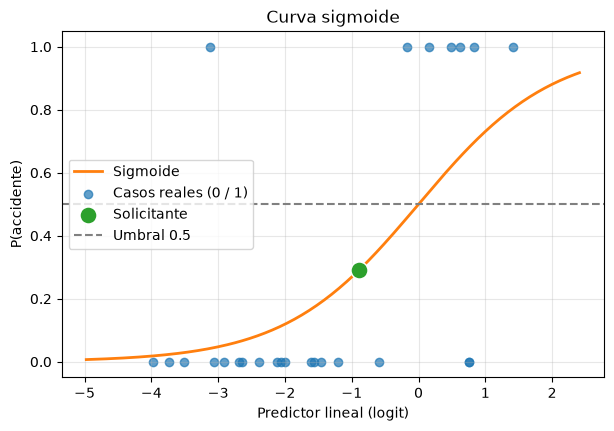

In [9]:
eta = logit.fittedvalues  # predictor lineal (logit) de cada caso
xs = np.linspace(min(eta.min(), z) - 1, max(eta.max(), z) + 1, 200)
plt.plot(xs, 1 / (1 + np.exp(-xs)), color="tab:orange", linewidth=2, label="Sigmoide")
plt.scatter(eta, df["AccEsteAño"], alpha=0.7, label="Casos reales (0 / 1)")
plt.scatter([z], [prob], s=150, color="tab:green", edgecolor="white", zorder=5, label="Solicitante")
plt.axhline(UMBRAL, ls="--", color="gray", label=f"Umbral {UMBRAL}")
plt.xlabel("Predictor lineal (logit)")
plt.ylabel("P(accidente)")
plt.legend(loc="center left")
plt.title("Curva sigmoide")
plt.show()

## 5. Matriz de confusión y métricas

Con un umbral de corte de 0,5 se pronostica **accidente** cuando $p \ge 0{,}5$.

In [10]:
y_real = df["AccEsteAño"]
p_est = logit.predict(df)
y_pred = (p_est >= UMBRAL).astype(int)

vn, fp, fn, vp = confusion_matrix(y_real, y_pred).ravel()
print(pd.crosstab(y_real, y_pred, rownames=["Real"], colnames=["Pronóstico"]), "\n")
print(f"VP = {vp}, FP = {fp}, FN = {fn}, VN = {vn}")
print("Coincide con la cátedra (VP=5, FP=2, FN=2, VN=16):", "✔" if (vp, fp, fn, vn) == (5, 2, 2, 16) else "✘")

pd.Series({
    "Accuracy": accuracy_score(y_real, y_pred),
    "Precision": precision_score(y_real, y_pred),
    "Recall (sensibilidad)": recall_score(y_real, y_pred),
    "Especificidad": vn / (vn + fp),
    "F-measure": f1_score(y_real, y_pred),
})

Pronóstico   0  1
Real             
0           16  2
1            2  5 

VP = 5, FP = 2, FN = 2, VN = 16
Coincide con la cátedra (VP=5, FP=2, FN=2, VN=16): ✔


Accuracy                0.8400
Precision               0.7143
Recall (sensibilidad)   0.7143
Especificidad           0.8889
F-measure               0.7143
dtype: float64

### Efecto del umbral de corte

In [11]:
filas = []
for u in np.arange(0.1, 0.91, 0.1):
    pred = (p_est >= u).astype(int)
    vn_, fp_, fn_, vp_ = confusion_matrix(y_real, pred, labels=[0, 1]).ravel()
    filas.append({
        "Umbral": round(u, 1), "VP": vp_, "FP": fp_, "FN": fn_, "VN": vn_,
        "Accuracy": accuracy_score(y_real, pred),
        "Precision": precision_score(y_real, pred, zero_division=0),
        "Recall": recall_score(y_real, pred),
        "F-measure": f1_score(y_real, pred, zero_division=0),
    })
pd.DataFrame(filas)

,Umbral,VP,FP,FN,VN,Accuracy,Precision,Recall,F-measure
0,0.1000,6,10,1,8,0.5600,0.3750,0.8571,0.5217
1,0.2000,6,4,1,14,0.8000,0.6000,0.8571,0.7059
2,0.3000,6,3,1,15,0.8400,0.6667,0.8571,0.7500
3,0.4000,6,2,1,16,0.8800,0.7500,0.8571,0.8000
4,0.5000,5,2,2,16,0.8400,0.7143,0.7143,0.7143
5,0.6000,4,2,3,16,0.8000,0.6667,0.5714,0.6154
6,0.7000,1,0,6,18,0.7600,1.0000,0.1429,0.2500
7,0.8000,1,0,6,18,0.7600,1.0000,0.1429,0.2500
8,0.9000,0,0,7,18,0.7200,0.0000,0.0000,0.0000


Al **subir** el umbral el modelo es más exigente para pronosticar accidente: bajan los falsos positivos
pero aumentan los falsos negativos (baja el recall).

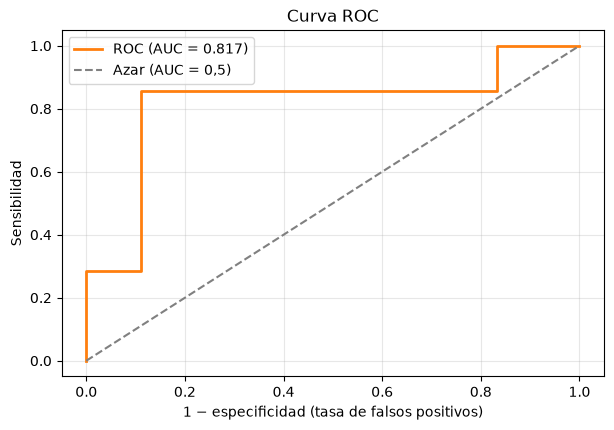

In [12]:
fpr, tpr, _ = roc_curve(y_real, p_est)
area = auc(fpr, tpr)
plt.step(fpr, tpr, where="post", color="tab:orange", linewidth=2, label=f"ROC (AUC = {area:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Azar (AUC = 0,5)")
plt.xlabel("1 − especificidad (tasa de falsos positivos)")
plt.ylabel("Sensibilidad")
plt.legend()
plt.title("Curva ROC")
plt.show()

## 6. Separación perfecta: usando solo las primeras 19 filas

Si con pocas observaciones existe una combinación de las X que **separa sin error** a los que tuvieron
accidente de los que no, la verosimilitud crece sin límite y los coeficientes se van a $\pm\infty$:
el modelo **no converge**. Veamos qué pasa con las primeras 19 filas.

In [13]:
primeras19 = df.head(19)
with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter("always")
    try:
        logit19 = smf.logit("AccEsteAño ~ Edad + MilesKm + AccAnterior", data=primeras19).fit(maxiter=100, disp=False)
        print("Coeficientes (no confiables):")
        print(logit19.params, "\n")
        print(f"−2LL = {-2 * logit19.llf:.6f}   (≈ 0: el modelo 'clasifica perfecto')")
        print("Probabilidades estimadas:", np.round(logit19.predict(primeras19).values, 4))
    except Exception as e:  # según la versión de statsmodels puede ser un error en lugar de un aviso
        print(f"Error: {type(e).__name__}: {e}")

for tipo, mensaje in dict.fromkeys((a.category.__name__, str(a.message)) for a in avisos):
    if "separation" in mensaje.lower() or "converge" in mensaje.lower():
        print(f"⚠ {tipo}: {mensaje}")

Coeficientes (no confiables):
Intercept     21.9437
Edad          -5.6315
MilesKm        5.2566
AccAnterior   27.6329
dtype: float64 

−2LL = 0.000000   (≈ 0: el modelo 'clasifica perfecto')
Probabilidades estimadas: [1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
⚠ PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
⚠ ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals


statsmodels avisa de la **separación perfecta** (o cuasi-perfecta): los coeficientes son enormes, −2LL
es prácticamente 0 y las probabilidades estimadas quedan pegadas a 0 o 1. Esos resultados **no son
válidos**. Con los 25 casos el problema desaparece porque aparecen observaciones que "rompen" la separación.

Soluciones habituales: conseguir más datos, quitar el predictor que separa o usar regresión penalizada (Firth).

## Conclusiones

- **logit(p) = −0,5621 − 0,0840·Edad + 0,0965·Km + 0,1619·AccAnt**, con χ² = 8,92 (p = 0,030) y
  $R^2$ de Nagelkerke = 0,432.
- El solicitante (30 años, 22,7 mil km, sin accidentes) tiene una probabilidad de accidente de **0,291**:
  con umbral 0,5 **se le otorga el seguro**.
- Con umbral 0,5: VP = 5, FP = 2, FN = 2, VN = 16 (accuracy = 84 %).

👉 En la web interactiva (pestaña **3. Seguro**) podés mover el umbral y ver la matriz de confusión en vivo.